# Gaussian Process Regression (GPR)

**Author:** Tara Hameed

## Contents
* [Introduction](#introduction)
* [What is a GP?](#what-is-a-gp)
* [Fitting a GP](#fitting-a-gp)
    + [Posterior predictive](#posterior-predictive)
    + [Marginal likelihood](#marginal-likelihood)
    + [Optimising hyperparameters in GPflow](#optimising-hyperparameters-in-gpflow)
* [Reference](#reference)

## Introduction
This small tutorial aims to recap classic GPR using GPflow. By the end of this notebook the goal is not to completely understand Gaussian Processes (GPs) but instead to get an intuition on what they are and how to practically fit them to data. All the explanations closely follow those of Williams and Rasmussen presented in the “Function-space View” in (Williams and Rasmussen, 2006). All examples also follow advice given in the [GPflow documentation](https://gpflow.github.io/GPflow/2.9.1/notebooks/getting_started/basic_usage.html). For a more detailed introduction please refer to (Williams and Rasmussen, 2006) and the [GPflow documentation](https://gpflow.github.io/GPflow/2.9.1/notebooks/getting_started/basic_usage.html).

The notebook starts by calling in the relevant packages:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import pandas as pd

import gpflow

np.random.seed(823094);

Below I've defined some helper functions to aide clarity/brevity of the examples below. Feel free to skip to the next cell!

In [3]:
## Helper functions

# define function to get prior samples of GP
def get_prior_f_samples(kernel, X_star, n_samples):
    K = kernel(X_star)  
    f_samples = np.random.multivariate_normal(np.zeros(len(X_star)), K, n_samples)
    # get mean and variance to plot confidence region
    f_var = np.diag(K)
    f_lower = - 1.96 * np.sqrt(f_var)
    f_upper = + 1.96 * np.sqrt(f_var)
    # put samples and confidence bands into dataframe for plotting
    df = pd.DataFrame(f_samples.T, columns=[f'Line {i+1}' for i in range(n_samples)])
    df.insert(0, "x", X_star[:, 0], allow_duplicates=True)
    return df.melt(id_vars='x', var_name='line', value_name='value'), f_lower, f_upper

# define function to get samples of fitted GP
def get_f_samples(chosen_model, X_star, n_samples):
    f_samples = chosen_model.predict_f_samples(X_star, n_samples)
    # get mean and variance to plot confidence region
    y_mean, y_var = chosen_model.predict_f(X_star, full_cov=False)
    y_lower = y_mean - 1.96 * np.sqrt(y_var)
    y_upper = y_mean + 1.96 * np.sqrt(y_var)
    # put samples and confidence bands into dataframe for plotting
    df = pd.DataFrame(f_samples[:, :, 0].numpy().T, columns=[f'Line {i+1}' for i in range(n_samples)])
    df.insert(0, "x", X_star[:, 0], allow_duplicates=True)
    return df.melt(id_vars='x', var_name='line', value_name='value'), y_lower, y_upper

# gets the log marginal likelihood for SquaredExponential kernel hyperparams (follows Algorithm 2.1, p.19, in (Williams and Rasmussen, 2006))
def get_lml(var, l, noise_var, Xo, Yo):
    num_data = len(Yo)
    K = gpflow.kernels.SquaredExponential(variance=var, lengthscales=l)
    K = K(Xo)
    k_diag = tf.linalg.diag_part(K)
    K = tf.linalg.set_diag(K, k_diag + noise_var)
    L = tf.linalg.cholesky(K)
    L_div_y = tf.linalg.triangular_solve(L, Yo, lower=True)
    alpha = tf.linalg.triangular_solve(tf.transpose(L), L_div_y, lower=False)
    lml = -0.5*tf.matmul(Yo.T, alpha) - 0.5*num_data*np.log(2*np.pi) - tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
    return tf.reduce_sum(lml)


## What is a GP?  

In (Williams and Rasmussen, 2006) a GP is defined as the following:

> A _Gaussian process_ is a collection of RVs, any finite number of which have a joint Gaussian distribution.

where a GP is specified using a mean function, $m(\boldsymbol{x})$, and a covariance function (or _kernel_), $k(\boldsymbol{x}, \boldsymbol{x}')$, for a vector of inputs $\boldsymbol{x}$:

$$ f(\boldsymbol{x}) \sim \mathcal{GP}(m(\boldsymbol{x}), k(\boldsymbol{x}, \boldsymbol{x}')).$$

A commonly chosen covariance function is the Squared Exponential: 

$$k(\boldsymbol{x}_i, \boldsymbol{x}_j) = \alpha^2\exp\left(\frac{-|\boldsymbol{x}_i-\boldsymbol{x}_j|^2}{2\rho^2}\right)$$

where $\boldsymbol{x}_i$ and $\boldsymbol{x}_j$ are both $D$ dimensional inputs and the output variance, $\alpha>0$, and length scale, $\rho > 0$, are both hyperparameters that control the scale of the output and how quickly the covariance decays, respectively. 

Instead of following the definition of a GP, it is often more intuitive to think of a GP as a distribution over _functions_ (Williams and Rasmussen, 2006). If we take the mean function, $m(\boldsymbol{x})$, to arbitrality be $\boldsymbol{0}$ and specify a covariance function, $k$, we can draw samples from a GP prior evaluated at many points i.e. evaluated at a $D \times n$ vector of inputs $X$: 

$$ \boldsymbol{f} \sim \mathcal{N}(\boldsymbol{0}, K(X, X)), $$

where $K(X, X)$ is a positive definite covariance matrix that equals $k(\boldsymbol{x}_i, \boldsymbol{x}_j)$ at the $(i, j)$-th index. 

Let's specify a covariance function, $k$, for set values for the variance, $\alpha$, and length scale, $\rho$, hyperparameters for a vector of inputs $X \in [0, 10]$ ($n=101, D=1$ in this simple example). Once we have specified our covariance function, we can draw 10 samples from the GP prior and plot them:

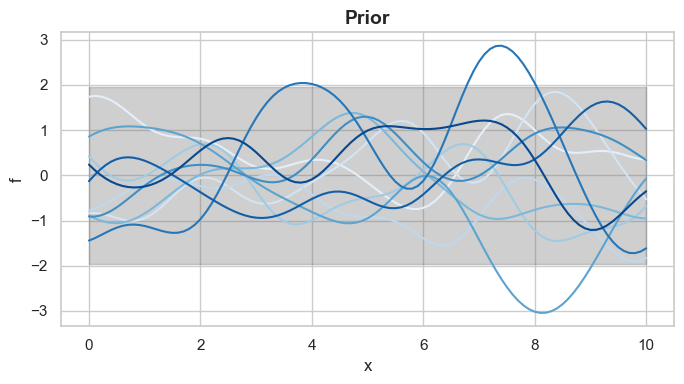

In [4]:
# specify hyperparam values
chosen_var = 1
chosen_l = 1
# specify 1D inputs
X = np.linspace(0.0, 10.0, num=101).reshape(-1, 1)  # GPflow actually takes X inputs in form n x D (101 x 1)
np.random.seed(823094)
n_samples = 10
kernel = gpflow.kernels.SquaredExponential(variance=chosen_var, lengthscales=chosen_l)
prior_df, f_prior_lower, f_prior_upper = get_prior_f_samples(kernel, X, n_samples)

# plot 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))       
plt.fill_between(
    X[:, 0], f_prior_lower, f_prior_upper, color="#636363", alpha=0.3
)
sns.lineplot(data = prior_df, x = "x", y = "value", palette="Blues", hue="line", linewidth=1.5, legend=False)
plt.ylabel("f", fontsize=12)
plt.title("Prior", fontsize=14, weight='bold')
plt.tight_layout()



Here the 95% confidence regions are shaded in grey and samples from the GP prior are shown in the blue lines. To get an intuition for the covariance function's hyperparameters you can change the values of `chosen_var` and `chosen_l` and rerun the cell above.

## Fitting a GP  

If you had observed data $\boldsymbol{y}$ for some observed data points $\boldsymbol{x}$ you could model this data as distributed around some unknown function $f$ with observed noise $\epsilon \sim \mathcal{N}(0, \sigma^2 I_n)$:

$$\boldsymbol{y} = f(\boldsymbol{x}) + \epsilon. $$

Instead of assuming a functional form for $f$, like $ f(\boldsymbol{x}) = a + b \boldsymbol{x}$ like in linear regression, or more complex differential equation models like $\frac{df}{dx} = \beta f$ for example, we can instead leave the form as unknown and place a GP prior over $f$. 

Let's first create some fake data by assuming the true functional form of $f$ is actually a sine curve; $\boldsymbol{y}_\text{obs} = \sin(\boldsymbol{x}_\text{obs}) + \epsilon$ for $\boldsymbol{x}_\text{obs}$ and a known noise level $\epsilon \sim \mathcal{N}(0, 0.1^2 I_n)$, where $n=7$:

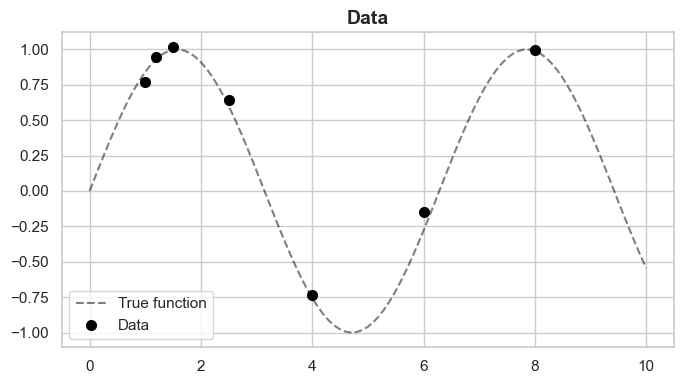

In [5]:
# specify some fake data:
# 1D input 
Xobs = np.array(
    [
        [1],
        [1.2],
        [1.5],
        [2.5],
        [4],
        [6],
        [8],
    ]
)
# sine curve of obs with added Gaussian noise that has scale of the chosen noise_std
noise_std = 0.1
Yobs = np.sin(Xobs) + noise_std * np.random.randn(*Xobs.shape)

# visualise the data
plt.figure(figsize=(7, 4))       
sns.lineplot(x = X[:, 0], y = np.sin(X[:, 0]), linewidth=1.5, linestyle="--", alpha=0.5, color = "black", label="True function")
plt.plot(Xobs, Yobs, "o", mew=2, color="black", label="Data")
plt.ylabel("")
plt.title("Data", fontsize=14, weight='bold')
plt.legend()
plt.tight_layout()

### Posterior predictive 

As mentioned above, we can model the data using 

$$\boldsymbol{y}_\text{obs} = f(\boldsymbol{x}_\text{obs}) + \epsilon, \; \epsilon \sim \mathcal{N}(0, \sigma^2 I_7),$$

and place a GP prior over $\boldsymbol{f}$. In doing so, we can analytically write down the joint distribution over $\boldsymbol{y}_\text{obs}$ and any GP predictions $\boldsymbol{f}_\star$ at test points $X_\star$ (Williams and Rasmussen, 2006):

$$
\begin{bmatrix}
\boldsymbol{y}_\text{obs} \\
\boldsymbol{f}_\star
\end{bmatrix}
\sim
\mathcal{N}\!\left(
\mathbf{0}, 
\begin{bmatrix}
K(X,X) + \sigma^2 I_n & K(X,X_\star) \\
K(X_\star,X) & K(X_\star,X_\star)
\end{bmatrix}
\right)
$$

where $X$ is now the observed data and we can also calculate the GP posterior predictive (Williams and Rasmussen, 2006):

$$\boldsymbol{f}_\star | X, \boldsymbol{y}, X_\star \sim \mathcal{N}(\mathbb{E}[\boldsymbol{f}_\star | X, \boldsymbol{y}, X_\star], \text{cov}(\boldsymbol{f}_\star)) $$

where the new mean and covariance are defined as:

$$\mathbb{E}[\boldsymbol{f}_\star | X, \boldsymbol{y}, X_\star] = K(X_\star, X)(K(X, X) + \sigma^2 I_n)^{-1}\boldsymbol{y}_{\text{obs}}$$

$$\text{cov}(\boldsymbol{f}_\star) = K(X_\star,X_\star) - K(X_\star,X) (K(X, X) + \sigma^2 I_n)^{-1} K(X, X_\star)$$

The equations may seem complicated but the important take home message is that when the noise, $\epsilon$, is assumed to be Gaussian, we can simply write down the form of the joint distribution over the data and also the predictions for the GP.

Let's calculate the above using `GPflow`:

In [6]:
# first specify GP model with observed data
model = gpflow.models.GPR(
    (Xobs, Yobs),
    kernel=gpflow.kernels.SquaredExponential(),
)

As we have specied that we are using classic GPR in the `GPflow` model, GPflow will calcualte the analytical posterior predictive when we call `predict_f_samples` on the model object. I've written a wrapper function around this (`get_f_samples`) just for simplicity in this notebook.

Let's calculate the predictions over a fine grid of points $X$ on $[0, 10]$: 

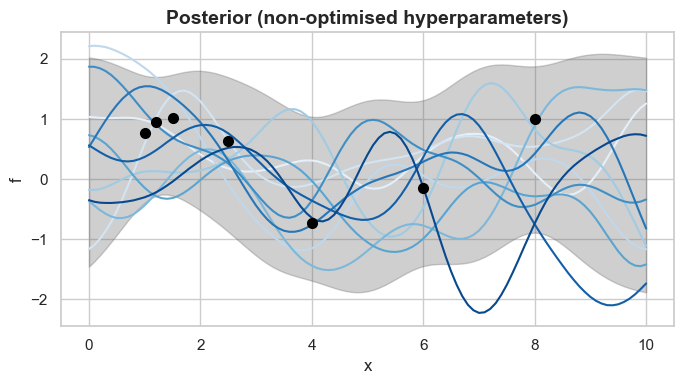

In [7]:
tf.random.set_seed(623874)
# get posterior predictive samples
df, f_lower, f_upper = get_f_samples(model, X, n_samples)

# plot GP samples
plt.figure(figsize=(7, 4))       
plt.fill_between(
    X[:, 0], f_lower[:, 0], f_upper[:, 0], color="#636363", alpha=0.3
)
sns.lineplot(data = df, x = "x", y = "value", palette="Blues", hue="line", linewidth=1.5, legend=False)
plt.plot(Xobs, Yobs, "o", mew=2, color="black", label="data")
plt.ylabel("f", fontsize=12)
plt.title("Posterior (non-optimised hyperparameters)", fontsize=14, weight='bold')
plt.tight_layout()

Why do these look ... _bad_? 

The answer is that even though we can analytically calculate the posterior predictive, $\boldsymbol{f}_\star | X, \boldsymbol{y}, X_\star \sim \mathcal{N}(\mathbb{E}[\boldsymbol{f}_\star | X, \boldsymbol{y}, X_\star], \text{cov}(\boldsymbol{f}_\star))$, this still depends on the hyperparameters ($\alpha, \rho$) of the chosen kernel! To see this, change the values in the kernel from the default and see how the posterior predictive changes. 

Additionally, the posterior predictive also depends on the noise scale $\sigma^2$. To see this, add in the following:

```
model.likelihood.variance.assign(noise_std**2)
```

to the above code cell before `get_f_samples` function is called and see how the fit is improved once $\sigma^2$ is set to the true noise variance. 

Still, changing the values manually is an inefficient way of fitting to the data. So, how do we find the _optimal_ values?

### Marginal likelihood 

To find appropriate values for the hyperparameters and the Gaussian noise scale, $\boldsymbol{\theta} = \{ \alpha, \rho, \sigma \}$, the marginal likelihood $p(\boldsymbol{y} | X, \boldsymbol{\theta})$ (also known as the model _evidence_) is often maximised, known as type II maximum likelihood (ML-II) (Williams and Rasmussen, 2006):

$$ p(\boldsymbol{y} | X, \boldsymbol{\theta}) = \int p(\boldsymbol{y} | X, \boldsymbol{f}, \boldsymbol{\theta}) p(\boldsymbol{f}| X, \boldsymbol{\theta}) d\boldsymbol{f}, $$

which is called the marginal likelihood because $\boldsymbol{f}$ has been marginalised out. The log of this marginal likelihood has a known analytical form in the case of a Gaussian likelihood for $\boldsymbol{y}$:

$$\log p(\boldsymbol{y} | X, \boldsymbol{\theta}) = - \frac{1}{2}\boldsymbol{y}^T[K(X, X) + \sigma^2 I_n]^{-1}\boldsymbol{y} -\frac{1}{2}\log|K(X, X) + \sigma^2 I_n|  -\frac{n}{2}\log(2\pi).$$

Williams and Rasmussen argue in Chapter 5 of (Williams and Rasmussen, 2006) that the first term of above represents the data fit, the second penalises complexity and the third is a normalising constant and hence maximising the marginal likelihood optimises the fit to the data whilst also avoiding overfitting.

Let's explore the marginal likelihood for varying hyperparameter values $\alpha$ and $\rho$ whilst keeping $\sigma$ fixed at it's true value:

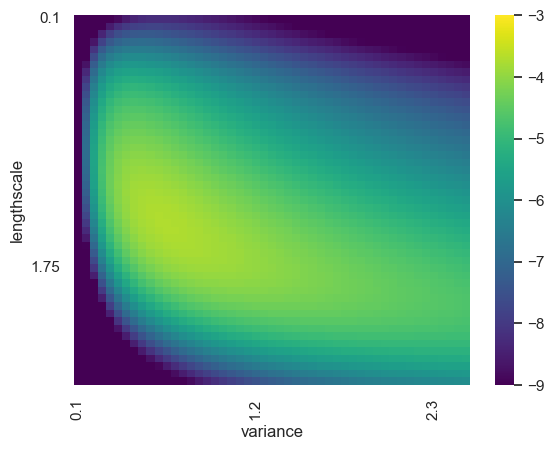

In [8]:
n_grid = 49

# specify ranges for output variance, alpha, and length scales, rho:
v_range = np.linspace(0.1, 2.5, num=n_grid)
l_range = np.linspace(0.1, 2.5, num=n_grid)

# evaluate log marginal likelihood (lml) on grid for different alphas and rhos 
Vars, Ls = np.meshgrid(v_range, l_range)
get_lml_v_l = lambda var, l, : get_lml(var, l, noise_std**2, Xobs, Yobs)  # sigma kept to its true value
lml_vec = np.vectorize(get_lml_v_l)
lmls = lml_vec(Vars, Ls)

# create data fram of lmls for plotting
d = {"variance" : Vars.flatten(), "lengthscale" : Ls.flatten(), "lmls" : lmls.flatten()}
lml_df = pd.DataFrame(d)
lml_heatmap_data = lml_df.pivot(index='lengthscale', columns='variance', values='lmls')

# plot heatmap
ax = sns.heatmap(lml_heatmap_data, cmap='viridis', vmin=-9, vmax=-3)
ax.set_xticks(ax.get_xticks()[::11])
ax.set_yticks(ax.get_yticks()[::11])

The above plot is shaded by the log marginal likelihood values for different kernel hyperparameter values. There is a region that has higher log marginal likelihood than the others. Simple optimisation algorthms can be used to find these regions to locate the optimal hyperparameter values and this is easily done in `GPflow`. 

### Optimising hyperparameters in GPflow  

To optimise the hyperparameters in GPflow, the negative log marginal likelihood is used as the training loss to be minimised:

In [9]:
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)
gpflow.utilities.print_summary(model, "notebook")

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,0.675188
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,1.47022
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.00151367


Notice how the values for the length scale and the output variance in the kernel fall in the higher log marginal likelihood region in the heatmap: 

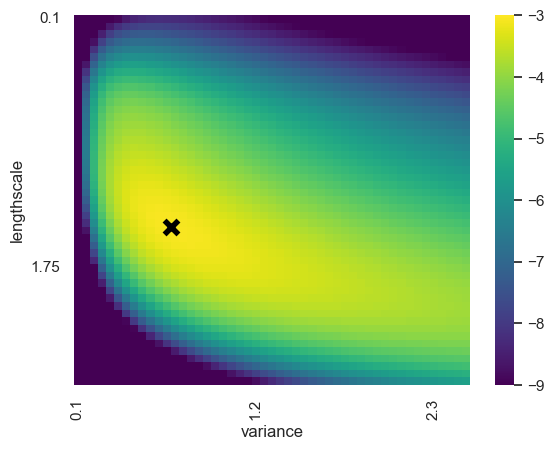

In [11]:
get_lml_v_l = lambda var, l, : get_lml(var, l, model.parameters[2].numpy(), Xobs, Yobs)  # sigma^2 now set to optimised value (vs true value before)
lml_vec = np.vectorize(get_lml_v_l)
lmls = lml_vec(Vars, Ls)

# create data fram of lmls for plotting
d = {"variance" : Vars.flatten(), "lengthscale" : Ls.flatten(), "lmls" : lmls.flatten()}
lml_df = pd.DataFrame(d)
lml_heatmap_data = lml_df.pivot(index='lengthscale', columns='variance', values='lmls')

# get indices on heatmap of optmised hyperparameter vals
optimal_var_index = np.min(np.where(v_range > model.parameters[1].numpy()))
optimal_ls_index = np.min(np.where(l_range > model.parameters[0].numpy()))

# plot heatmap and optmised vals
ax = sns.heatmap(lml_heatmap_data, cmap='viridis', vmin=-9, vmax=-3)
ax.scatter(y=optimal_ls_index, x=optimal_var_index, marker="x", s=100, linewidth=4, color="black")
ax.set_xticks(ax.get_xticks()[::11])
ax.set_yticks(ax.get_yticks()[::11])

We can now plot the posterior predictive samples using the optimal hyperparameter values, $\hat{\boldsymbol{\theta}}$, to see our fitted GP:

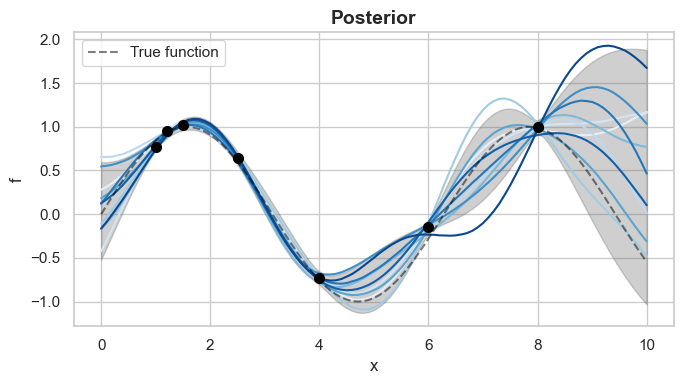

In [12]:
tf.random.set_seed(623874)
df, f_lower, f_upper = get_f_samples(model, X, n_samples)

# plot samples vs data and true function
plt.figure(figsize=(7, 4))       
plt.fill_between(
    X[:, 0], f_lower[:, 0], f_upper[:, 0], color="#636363", alpha=0.3
)
sns.lineplot(data = df, x = "x", y = "value", palette="Blues", hue="line", linewidth=1.5, legend=False)
sns.lineplot(x = X[:, 0], y = np.sin(X[:, 0]), linewidth=1.5, linestyle="--", alpha=0.5, color = "black", label="True function")
plt.plot(Xobs, Yobs, "o", mew=2, color="black", label="data")
plt.ylabel("f", fontsize=12)
plt.title("Posterior", fontsize=14, weight='bold')
plt.tight_layout()

We can see that the true function lies inside the 95% confidence region (shaded grey) of the fitted GP.

Try changing the data to see how GPR changes with increased noise scale ($\sigma$), different amounts of data and differently spaced data (values of `Xobs`). 

Hopefully this has been a helpful recap of GPR!

## Reference 
C. K. Williams and C. E. Rasmussen. _Gaussian processes for machine learning_. Vol. 2. 3. MIT press Cambridge, MA, 2006. 